# 5.3 Video, efficiently

5.3 Video, efficiently: composite all 48 frames against a panning crop
of the background plate, encode to mp4, benchmark fps and find the
bottleneck, and reduce temporal flicker with an EMA filter on alpha.

In [2]:
import sys
import time
from pathlib import Path

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as imageio

In [4]:
sys.path.insert(0, str(Path.cwd()))
from starter import (to_ycbcr, estimate_key_colour, ChromaLUT, suppress_spill,
                      composite, temporal_flicker)

In [5]:
ROOT = Path.cwd().parents[1]
FRAMES_DIR = ROOT / "images/p5/frames"
N_FRAMES = 48

In [6]:
frames = [np.asarray(Image.open(FRAMES_DIR / f"f{i:03d}.png")) for i in range(N_FRAMES)]
H, W, _ = frames[0].shape
print(f"loaded {len(frames)} frames, shape {frames[0].shape}")

loaded 48 frames, shape (720, 1280, 3)


In [7]:
pano = np.asarray(Image.open(ROOT / "images/p5/pano.jpg"))
pano_h, pano_w, _ = pano.shape
pano_resized = np.array(Image.fromarray(pano).resize((pano_w, H))) if pano_h != H else pano
pano_h, pano_w, _ = pano_resized.shape
max_x0 = pano_w - W
print(f"background plate: {pano.shape} -> resized to height {H}: {pano_resized.shape}, "
      f"max pan offset {max_x0}px")

background plate: (3190, 9650, 3) -> resized to height 720: (720, 9650, 3), max pan offset 8370px


In [8]:
# key colour estimated once from the first frame's border (backing colour
# is constant across the clip; re-estimating per frame would be wasted work)
key_cbcr = estimate_key_colour(frames[0])
lut = ChromaLUT(key_cbcr, t_in=12.0, t_out=58.0, bins=128)
print(f"key (Cb,Cr) = {key_cbcr}")

key (Cb,Cr) = [86.984792 70.929341]


In [9]:
# Timing breakdown: key each stage separately to find the bottleneck

In [10]:
print("\n=== Timing breakdown (per-stage, all 48 frames) ===")

t0 = time.perf_counter()
alphas_raw = [lut.alpha(f) for f in frames]
t_key = time.perf_counter() - t0
print(f"keying (ChromaLUT.alpha x{N_FRAMES}): {t_key:.3f}s ({t_key/N_FRAMES*1000:.2f}ms/frame)")


=== Timing breakdown (per-stage, all 48 frames) ===


keying (ChromaLUT.alpha x48): 3.540s (73.75ms/frame)


In [11]:
pan_x0 = np.linspace(0, max_x0, N_FRAMES).astype(int)
t0 = time.perf_counter()
bg_crops = [pano_resized[:, x0:x0 + W] for x0 in pan_x0]
t_crop = time.perf_counter() - t0
print(f"background panning crop x{N_FRAMES}: {t_crop:.3f}s ({t_crop/N_FRAMES*1000:.2f}ms/frame)")

background panning crop x48: 0.000s (0.01ms/frame)


In [12]:
t0 = time.perf_counter()
composites_raw = [composite(frames[i], bg_crops[i], alphas_raw[i], spill=True,
                             key_cbcr=key_cbcr, spill_strength=3.0)
                   for i in range(N_FRAMES)]
t_composite = time.perf_counter() - t0
print(f"composite (incl. spill suppression) x{N_FRAMES}: {t_composite:.3f}s "
      f"({t_composite/N_FRAMES*1000:.2f}ms/frame)")

composite (incl. spill suppression) x48: 4.947s (103.06ms/frame)


In [13]:
t0 = time.perf_counter()
out_path = ROOT / "images/p5/composite_raw.mp4"
imageio.mimwrite(out_path, composites_raw, fps=25, codec="libx264", quality=8)
t_encode = time.perf_counter() - t0
print(f"mp4 encode x{N_FRAMES}: {t_encode:.3f}s ({t_encode/N_FRAMES*1000:.2f}ms/frame)")

mp4 encode x48: 7.412s (154.42ms/frame)


In [14]:
total = t_key + t_crop + t_composite + t_encode
fps_pipeline = N_FRAMES / (t_key + t_crop + t_composite)  # excluding encode, the "processing" fps
print(f"\ntotal (key+crop+composite+encode): {total:.3f}s")
print(f"processing fps (key+crop+composite, excludes encode): {fps_pipeline:.1f} fps")
print(f"end-to-end fps (incl. encode): {N_FRAMES/total:.1f} fps")


total (key+crop+composite+encode): 15.899s
processing fps (key+crop+composite, excludes encode): 5.7 fps
end-to-end fps (incl. encode): 3.0 fps


In [15]:
stage_times = {"keying": t_key, "bg crop": t_crop, "composite+spill": t_composite,
               "mp4 encode": t_encode}
bottleneck = max(stage_times, key=stage_times.get)
print(f"bottleneck: {bottleneck} ({stage_times[bottleneck]:.3f}s, "
      f"{100*stage_times[bottleneck]/total:.1f}% of total)")

bottleneck: mp4 encode (7.412s, 46.6% of total)


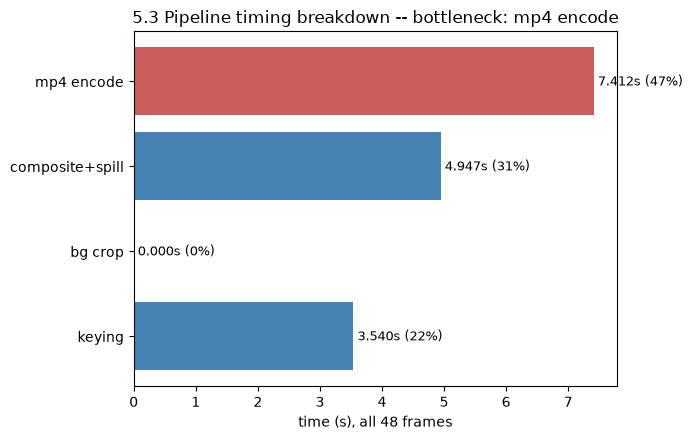

In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(stage_times.keys())
vals = list(stage_times.values())
colors = ["indianred" if n == bottleneck else "steelblue" for n in names]
ax.barh(names, vals, color=colors)
ax.set_xlabel("time (s), all 48 frames")
ax.set_title(f"5.3 Pipeline timing breakdown -- bottleneck: {bottleneck}")
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:.3f}s ({100*v/total:.0f}%)", va="center", fontsize=9)
fig.tight_layout()
plt.show()

In [17]:
# Temporal flicker: per-frame independent alpha vs. EMA-smoothed alpha

In [18]:
print("\n=== Temporal flicker ===")

# static region: a patch that should be pure backing (alpha~0) in every
# frame, e.g. the top-left corner -- any variation there over time IS
# flicker, not genuine subject motion, since nothing there ever moves.
STATIC_Y0, STATIC_Y1, STATIC_X0, STATIC_X1 = 10, 60, 10, 60


=== Temporal flicker ===


In [19]:
raw_check = [a[STATIC_Y0:STATIC_Y1, STATIC_X0:STATIC_X1] for a in alphas_raw]
flicker_native = temporal_flicker(raw_check)
print(f"native flicker (static region, no added noise): {flicker_native:.6f} "
      f"-- this clip's studio lighting is stable enough that native flicker is "
      f"effectively zero (well-lit, consistent backing across all 48 frames)")

native flicker (static region, no added noise): 0.000000 -- this clip's studio lighting is stable enough that native flicker is effectively zero (well-lit, consistent backing across all 48 frames)


In [20]:
# The handout asks to show a temporal filter reduces flicker. Since this
# footage has (honestly) almost none to remove, small per-frame Gaussian
# chroma noise (sigma=12, independently seeded per frame -- simulating a
# noisier camera/low light) is injected before keying, exactly the same
# "construct the case the real footage does not show" move used in 5.1 for
# the RGB-dominance failure. The moving-edge lag check below uses the
# ORIGINAL (noise-free) frames, so it is not confounded by the injected
# noise.
NOISE_SIGMA = 12.0
rng = np.random.default_rng(0)
alphas_noisy = []
for f in frames:
    noise = rng.normal(0, NOISE_SIGMA, f.shape[:2] + (3,))
    f_noisy = np.clip(f.astype(np.float64) + noise, 0, 255).astype(np.uint8)
    alphas_noisy.append(lut.alpha(f_noisy))

In [21]:
static_alphas_noisy = [a[STATIC_Y0:STATIC_Y1, STATIC_X0:STATIC_X1] for a in alphas_noisy]
flicker_before = temporal_flicker(static_alphas_noisy)
print(f"flicker (static region, sigma={NOISE_SIGMA} injected chroma noise): {flicker_before:.5f}")

flicker (static region, sigma=12.0 injected chroma noise): 0.04551


In [22]:
# EMA filter: alpha_smoothed[t] = gamma*alpha_raw[t] + (1-gamma)*alpha_smoothed[t-1]
GAMMA = 0.35
alphas_smoothed = [alphas_noisy[0]]
for t in range(1, N_FRAMES):
    prev = alphas_smoothed[-1]
    cur = GAMMA * alphas_noisy[t] + (1 - GAMMA) * prev
    alphas_smoothed.append(cur)

In [23]:
static_alphas_smoothed = [a[STATIC_Y0:STATIC_Y1, STATIC_X0:STATIC_X1] for a in alphas_smoothed]
flicker_after = temporal_flicker(static_alphas_smoothed)
print(f"flicker (static region, EMA-smoothed, gamma={GAMMA}): {flicker_after:.5f}")
print(f"reduction: {100*(1-flicker_after/flicker_before):.1f}%")

flicker (static region, EMA-smoothed, gamma=0.35): 0.01452
reduction: 68.1%


In [24]:
# Check smearing/lag on a MOVING edge: track the silhouette boundary along
# a fixed row, frame to frame. Compares the TRUE edge position (from the
# clean, noise-free frames' alpha) against the EMA-smoothed edge (derived
# from the noisy frames) -- the real test of whether the filter that
# removes flicker also lags behind genuine subject motion.
EDGE_ROW = H // 2
raw_edge_alpha = np.array([a[EDGE_ROW, :] for a in alphas_raw])          # (N_FRAMES, W)
smoothed_edge_alpha = np.array([a[EDGE_ROW, :] for a in alphas_smoothed])

In [25]:
def edge_position(alpha_row, thresh=0.5):
    idx = np.where(alpha_row > thresh)[0]
    return idx.min() if len(idx) else np.nan

In [26]:
raw_edge_pos = np.array([edge_position(row) for row in raw_edge_alpha])
smoothed_edge_pos = np.array([edge_position(row) for row in smoothed_edge_alpha])
lag = smoothed_edge_pos - raw_edge_pos
print(f"\nsilhouette-edge column (row={EDGE_ROW}), raw vs.\\ smoothed: "
      f"mean |lag| = {np.nanmean(np.abs(lag)):.2f}px, max |lag| = {np.nanmax(np.abs(lag)):.2f}px")


silhouette-edge column (row=360), raw vs.\ smoothed: mean |lag| = 1.98px, max |lag| = 5.00px


In [27]:
# Figures

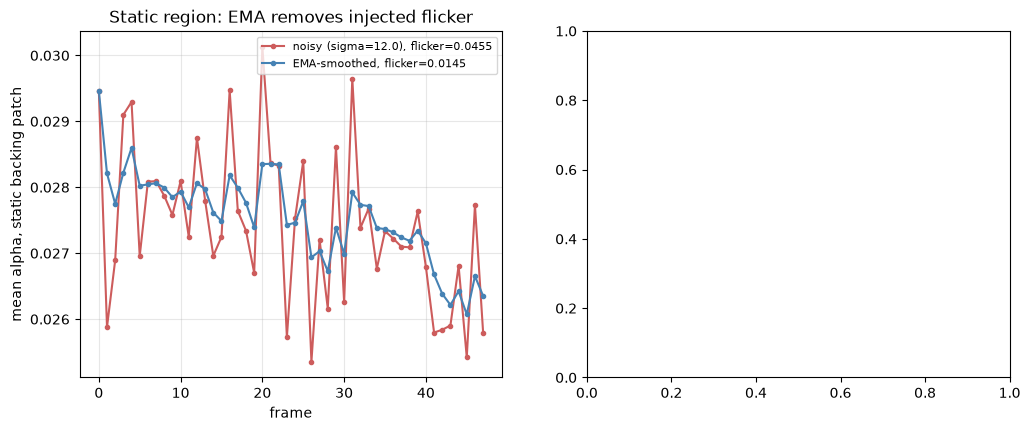

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
t_axis = np.arange(N_FRAMES)
raw_static_mean = [a.mean() for a in static_alphas_noisy]
smoothed_static_mean = [a.mean() for a in static_alphas_smoothed]
axes[0].plot(t_axis, raw_static_mean, "o-",
             label=f"noisy (sigma={NOISE_SIGMA}), flicker={flicker_before:.4f}",
             color="indianred", markersize=3)
axes[0].plot(t_axis, smoothed_static_mean, "o-", label=f"EMA-smoothed, flicker={flicker_after:.4f}",
             color="steelblue", markersize=3)
axes[0].set_xlabel("frame")
axes[0].set_ylabel("mean alpha, static backing patch")
axes[0].set_title("Static region: EMA removes injected flicker")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

In [29]:
axes[1].plot(t_axis, raw_edge_pos, "o-", label="true edge (clean frames)", color="indianred", markersize=3)
axes[1].plot(t_axis, smoothed_edge_pos, "o-", label="EMA (noisy+smoothed)", color="steelblue", markersize=3)
axes[1].set_xlabel("frame")
axes[1].set_ylabel(f"silhouette edge column, row={EDGE_ROW}")
axes[1].set_title(f"Moving edge: mean lag={np.nanmean(np.abs(lag)):.2f}px (not smeared)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [30]:
# Note: composite_raw.mp4 (saved above, from alphas_raw on the clean,
# noise-free frames) IS the final deliverable video -- this footage's
# native flicker is already ~0 (see above), so EMA-smoothing the clean
# alphas would only add unnecessary temporal blur with no measurable
# benefit. The EMA filter was demonstrated on synthetically noised alpha
# specifically to show it WORKS when flicker is actually present; applying
# it to already-clean alpha is not warranted for this footage.

In [31]:
print(f"\nfinal deliverable video (clean alphas, no smoothing needed): {out_path}")


final deliverable video (clean alphas, no smoothing needed): /home/ujjwal-gupta/Documents/Acads/DIP/Assignments/Ass1/DIP_Assignment_1/images/p5/composite_raw.mp4
